# [QPLIB](https://qplib.zib.de/index.html)
Furini, F., Traversi, E., Belotti, P. et al. QPLIB: a library of quadratic programming instances. Math. Prog. Comp. 11, 237–265 (2019). https://doi.org/10.1007/s12532-018-0147-4

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qci-wdyk/eqc-models-tutorial/blob/main/tutorial08-qplib.ipynb)

## QPLIB with eqc-models
### QCL
Solving three QCL models. These are quadratic, continuous models with linear constraints. They are a natural fit for Dirac-3 because of the single constraint each has: the sum of all decision variables is equal to 1. 

In [104]:
try:
    import eqc_models
except ImportError:
    !pip install eqc-models
import os
import os.path
import numpy as np
import matplotlib.pyplot as plt
from eqc_models.utilities.qplib import file_to_model
from eqc_models.solvers import Dirac3ContinuousCloudSolver, Dirac3IntegerCloudSolver
file_names = {"0018": "QPLIB_0018.qplib",
              "2712": "QPLIB_2712.qplib",
              "2761": "QPLIB_2761.qplib",
              "5881": "QPLIB_5881.qplib"}
for key in file_names:
    if not os.path.exists(file_names[key]):
        fname = file_names[key]
        !curl https://qplib.zib.de/qplib/$fname > $fname
try:
    from google.colab import userdata
except ImportError:
    userdata = None

#eqc-models 0.21.0 crashes where evaluate returns a list; we can require it to return a single float to get around this. 
from eqc_models.base.operators import Polynomial
from eqc_models.base.polynomial import ConstrainedPolynomialModel
_orig_poly_evaluate = Polynomial.evaluate

def _scalar_evaluate(self, solution):
    res = _orig_poly_evaluate(self, solution)
    arr = np.asarray(res).ravel()
    return float(arr[0]) if arr.size else 0.0
Polynomial.evaluate = _scalar_evaluate

In [105]:
# Define the API URL and token  for QCI
if userdata is None:
    api_token = "Z!tG1IEyIVI9ZG*HLZrdBMB6JHax5TX=**^Bfy#pCfpsG1=z" # replace or use environment variables to configure
    api_url = "https://api.qci-prod.com"
else:
    api_token = userdata.get("QCI_TOKEN")
    api_url = userdata.get("QCI_API_URL")
    os.environ["QCI_TOKEN"] = api_token
    os.environ["QCI_API_URL"] = api_url

## [QPLIB_0018](https://qplib.zib.de/QPLIB_0018.html)

50 nonnegative variables with all quadratic terms.

In [106]:
sum_constraint = 1
model = file_to_model(open(file_names["0018"]))
model.upper_bound = np.array([sum_constraint for i in range(model.n)])
model.penalty_multiplier = 0  # already baked into the Hamiltonian

# Only force evaluatePenalties to return a pure Python float.
# results.py will still add model.offset itself.
_orig = model.evaluatePenalties
model.evaluatePenalties = lambda sol: float(np.asarray(_orig(sol)).item())

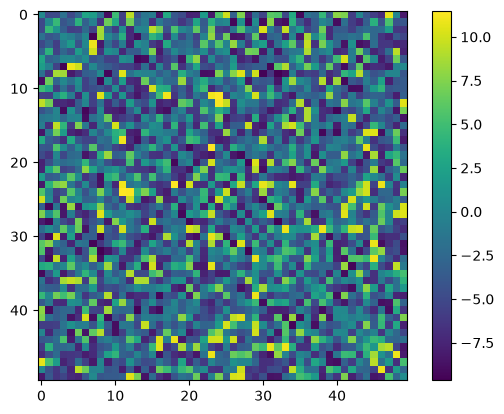

In [107]:
plt.imshow(model.qubo.Q)
cb = plt.colorbar()

In [108]:
solver = Dirac3ContinuousCloudSolver(api_url,api_token)

In [109]:
response = solver.solve(model, num_samples=5, relaxation_schedule=1, sum_constraint=1)
print(response["results"]["energies"])
for k, v in zip(range(len(response["results"]["solutions"][0])), response["results"]["solutions"][0]):
    if v > 0:
        print(k+2, v)
metrics = solver.getMetrics(response["job_info"]["job_id"])

2026-09-10 16:33:16 - Dirac allocation balance = 0 s (unmetered)
2026-09-10 16:33:16 - Job submitted: job_id='6aa3140d08442f441bbb6f21'
2026-09-10 16:33:16 - QUEUED
2026-09-10 16:33:19 - RUNNING
2026-09-10 16:33:21 - COMPLETED
2026-09-10 16:33:24 - Dirac allocation balance = 0 s (unmetered)
[-6.3858814, -6.3854575, -6.3852601, -5.9759994, -5.7711844]
15 0.2064518
18 0.2777356
33 2e-07
40 0.2277121
42 0.2881002


In [110]:
runtime = metrics["job_metrics"]["time_ns"]["device"]["dirac-3_normalized_qudit"]["samples"]["runtime"]
postprocessing = metrics["job_metrics"]["time_ns"]["device"]["dirac-3_normalized_qudit"]["samples"]["postprocessing_time"]
preprocessing = metrics["job_metrics"]["time_ns"]["device"]["dirac-3_normalized_qudit"]["samples"]["preprocessing_time"]
print(f"Preprocessing time: {preprocessing/1e9}s")
for r, p in zip(runtime, postprocessing):
    print(f"Sample runtime + postprocessing {(r+p)/1e9}s")

Preprocessing time: 0.173386618s
Sample runtime + postprocessing 0.270550072s
Sample runtime + postprocessing 0.299353182s
Sample runtime + postprocessing 0.255953223s
Sample runtime + postprocessing 0.304675192s
Sample runtime + postprocessing 0.240961552s


[0018 solution](https://qplib.zib.de/sol/QPLIB_0018.sol)

## [QPLIB 2712](https://qplib.zib.de/sol/QPLIB_2712.sol)

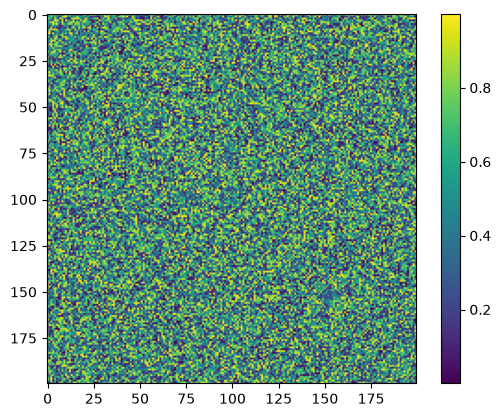

In [111]:
model = file_to_model(open(file_names["2712"]))
model.upper_bound = np.array([sum_constraint for i in range(model.linear_objective.shape[0])])
model.penalty_multiplier = 0 # the qplib import reads the constraint into the hamiltonian, so this eliminates it

_orig = model.evaluatePenalties
model.evaluatePenalties = lambda sol: float(np.asarray(_orig(sol)).ravel()[0])

from eqc_models.base.operators import Polynomial
_orig_poly = Polynomial.evaluate
def _scalar_evaluate(self, solution):
    res = _orig_poly(self, solution)
    arr = np.asarray(res).ravel()
    return float(arr[0]) if arr.size else 0.0
Polynomial.evaluate = _scalar_evaluate
plt.imshow(model.qubo.Q)
cb = plt.colorbar()

In [112]:

response = solver.solve(model, num_samples=5, relaxation_schedule=1, sum_constraint=1)
print(response["results"]["energies"])
for k, v in zip(range(len(response["results"]["solutions"][0])), response["results"]["solutions"][0]):
    if v > 0:
        print(k+2, v)
metrics = solver.getMetrics(job_id=response["job_info"]["job_id"])

2026-09-10 16:33:29 - Dirac allocation balance = 0 s (unmetered)
2026-09-10 16:33:30 - Job submitted: job_id='6aa3141b08442f441bbb6f22'
2026-09-10 16:33:30 - QUEUED
2026-09-10 16:33:32 - RUNNING
2026-09-10 16:33:37 - COMPLETED
2026-09-10 16:33:40 - Dirac allocation balance = 0 s (unmetered)
[0.0625995, 0.0990102, 0.1207134, 0.1283959, 0.1345213]
19 1e-07
40 1e-07
61 0.0002014
63 0.3119495
111 0.2613221
198 0.4265267


In [113]:
runtime = metrics["job_metrics"]["time_ns"]["device"]["dirac-3_normalized_qudit"]["samples"]["runtime"]
postprocessing = metrics["job_metrics"]["time_ns"]["device"]["dirac-3_normalized_qudit"]["samples"]["postprocessing_time"]
preprocessing = metrics["job_metrics"]["time_ns"]["device"]["dirac-3_normalized_qudit"]["samples"]["preprocessing_time"]
print(f"Preprocessing time: {preprocessing/1e9}s")
for r, p in zip(runtime, postprocessing):
    print(f"Sample runtime + postprocessing {(r+p)/1e9}s")

Preprocessing time: 0.757919014s
Sample runtime + postprocessing 0.677277207s
Sample runtime + postprocessing 0.652570963s
Sample runtime + postprocessing 1.104731083s
Sample runtime + postprocessing 1.144172907s
Sample runtime + postprocessing 0.770961046s


[2712 Solution](https://qplib.zib.de/sol/QPLIB_2712.sol)

## [QPLIB 2761](https://qplib.zib.de/QPLIB_2761.html)



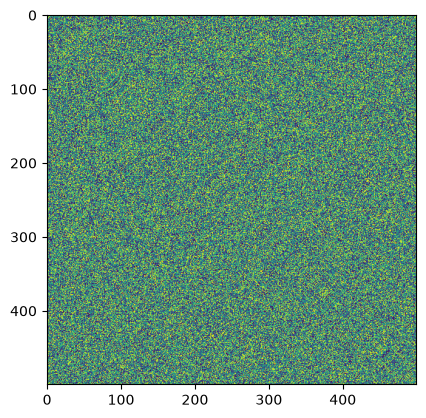

In [114]:
model = file_to_model(open(file_names["2761"]))
model.upper_bound = np.array([sum_constraint for i in range(model.linear_objective.shape[0])])
model.penalty_multiplier = 0

_orig = model.evaluatePenalties

class _Scalar:
    def __init__(self, v):
        self.v = float(np.asarray(v).ravel().sum())
    def __add__(self, other):
        return self.v + float(np.asarray(other).ravel().sum())
    __radd__ = __add__

model.evaluatePenalties = lambda sol: _Scalar(_orig(sol))

plt.imshow(model.qubo.Q)

In [115]:

response = solver.solve(model, num_samples=10, relaxation_schedule=2, sum_constraint=1)
print(response["results"]["energies"])
for k, v in zip(range(len(response["results"]["solutions"][0])), response["results"]["solutions"][0]):
    if v > 0:
        print(k+2, v)
metrics = solver.getMetrics(job_id=response["job_info"]["job_id"])

2026-09-10 16:33:47 - Dirac allocation balance = 0 s (unmetered)
2026-09-10 16:33:47 - Job submitted: job_id='6aa3142d08442f441bbb6f23'
2026-09-10 16:33:47 - RUNNING
2026-09-10 16:34:34 - COMPLETED
2026-09-10 16:34:37 - Dirac allocation balance = 0 s (unmetered)
[0.0477931, 0.0667214, 0.0792091, 0.082487, 0.0841002, 0.121176, 0.134276, 0.1345455, 0.16031, 0.1701562]
7 5.9e-06
14 1e-07
18 1e-07
28 1e-07
35 1e-07
62 6e-07
76 1e-07
135 1.9e-06
137 1.6e-06
138 6e-07
168 0.0062197
169 1.5e-06
171 1.36e-05
194 8e-07
199 3e-07
230 0.9118468
252 2.6e-06
281 9e-07
311 0.0719448
313 1.02e-05
335 2e-07
336 4e-07
340 6e-07
341 2e-07
349 9.3e-06
353 2.3e-06
362 4e-07
364 0.0001273
367 2e-07
376 1e-06
408 1.47e-05
414 0.0082546
423 0.0014449
429 6e-07
434 3.59e-05
439 4e-07
445 1.95e-05
447 3.04e-05
460 3.5e-06
464 3e-07
474 5e-07


[2761 Solution](https://qplib.zib.de/sol/QPLIB_2761.sol)

In [116]:
runtime = metrics["job_metrics"]["time_ns"]["device"]["dirac-3_normalized_qudit"]["samples"]["runtime"]
postprocessing = metrics["job_metrics"]["time_ns"]["device"]["dirac-3_normalized_qudit"]["samples"]["postprocessing_time"]
preprocessing = metrics["job_metrics"]["time_ns"]["device"]["dirac-3_normalized_qudit"]["samples"]["preprocessing_time"]
print(f"Preprocessing time: {preprocessing/1e9}s")
for r, p in zip(runtime, postprocessing):
    print(f"Sample runtime + postprocessing {(r+p)/1e9}s")

Preprocessing time: 2.312140942s
Sample runtime + postprocessing 3.598611116s
Sample runtime + postprocessing 3.450075626s
Sample runtime + postprocessing 7.359142303s
Sample runtime + postprocessing 3.793519497s
Sample runtime + postprocessing 3.616988897s
Sample runtime + postprocessing 3.533530951s
Sample runtime + postprocessing 3.754512072s
Sample runtime + postprocessing 3.497222662s
Sample runtime + postprocessing 3.487089872s
Sample runtime + postprocessing 3.554977179s


## QPLIB 5881

QUBO

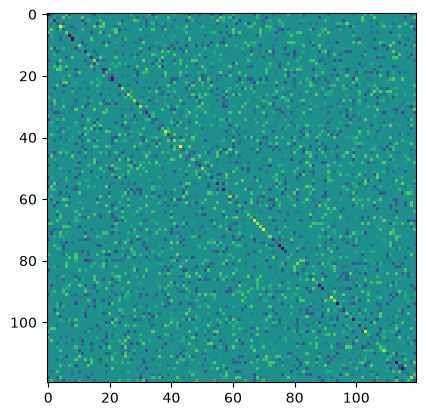

In [ ]:
model = file_to_model(open(file_names["5881"]))
model.upper_bound = np.array([1 for i in range(model.n)])
model.penalty_multiplier = 0

_orig = model.evaluatePenalties

class _Scalar:
    def __init__(self, v):
        self.v = float(np.asarray(v).ravel().sum())
    def __add__(self, other):
        return self.v + float(np.asarray(other).ravel().sum())
    __radd__ = __add__

model.evaluatePenalties = lambda sol: _Scalar(_orig(sol))
plt.imshow(model.qubo.Q)

In [118]:
solver = Dirac3IntegerCloudSolver(url=api_url, api_token=api_token)

In [119]:
response = solver.solve(model, num_samples=5, relaxation_schedule=1, mean_photon_number=0.00075)
print("Best", -13067, "Samples", response["results"]["energies"])
for k, v in zip(range(len(response["results"]["solutions"][0])), response["results"]["solutions"][0]):
    if v > 0:
        print(k+2, v)
metrics = solver.getMetrics(job_id=response["job_info"]["job_id"])

2026-09-10 16:34:41 - Dirac allocation balance = 0 s (unmetered)
2026-09-10 16:34:42 - Job submitted: job_id='6aa3146308442f441bbb6f24'
2026-09-10 16:34:42 - QUEUED
2026-09-10 16:34:44 - RUNNING
2026-09-10 16:35:44 - COMPLETED
2026-09-10 16:35:47 - Dirac allocation balance = 0 s (unmetered)


ValueError: setting an array element with a sequence.

In [ ]:
runtime = metrics["job_metrics"]["time_ns"]["device"]["dirac-3_qudit"]["samples"]["runtime"]
for r in runtime:
    print(f"Sample runtime {(r)/1e9}s")

Sample runtime 5.587146282s
Sample runtime 6.108756065s
Sample runtime 5.466411591s
Sample runtime 5.024880409s
Sample runtime 4.991193771s
